In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import geopandas as gpd
from shapely import wkt
from shapely.geometry import Point

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/final_csv/원본 파일/Chicago_Crimes_2001_to_2004.csv', on_bad_lines='skip')

<ipython-input-60-cd3d5b6b00c2>:1: DtypeWarning: Columns (17,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/final_csv/원본 파일/Chicago_Crimes_2001_to_2004.csv', on_bad_lines='skip')


In [ ]:
df = df.dropna(subset=['X Coordinate','Y Coordinate','Latitude', 'Longitude', 'Location'])

In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
ID,0
Case Number,0
Date,0
Block,0
IUCR,0
Primary Type,0
Description,0
Location Description,13
Arrest,0


In [ ]:
# 3. 범죄 데이터의 위도, 경도 정보를 사용해 GeoDataFrame 생성
df['geometry'] = df.apply(lambda row: Point(row['Longitude'], row['Latitude']), axis=1)
crime_gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")  # WGS84 좌표계 설정

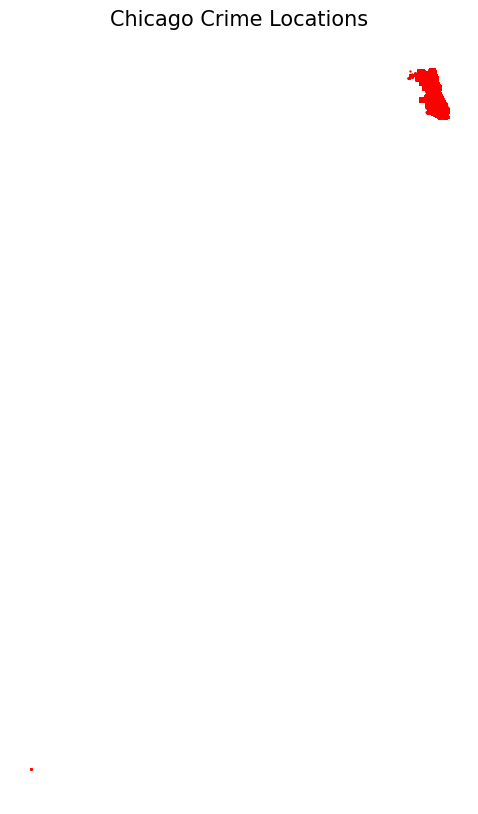

In [ ]:
import matplotlib.pyplot as plt

# 범죄 데이터 시각화
fig, ax = plt.subplots(figsize=(10, 10))  # 크기 조정
crime_gdf.plot(ax=ax, color='red', markersize=0.5)  # 범죄 사건을 빨간색 점으로 시각화

# 제목 추가
ax.set_title("Chicago Crime Locations", fontsize=15)

# 축 숨기기
ax.set_axis_off()

# 시각화 출력
plt.show()


In [ ]:
# 4. Community Area CSV 파일 불러오기 (the_geom을 WKT 형식으로 변환)
community_areas = pd.read_csv('/content/drive/MyDrive/final_csv/CommAreas_20250325.csv')  # Community Area 데이터 (CSV)
community_areas['geometry'] = community_areas['the_geom'].apply(wkt.loads)  # the_geom을 WKT로 변환
community_areas_gdf = gpd.GeoDataFrame(community_areas, geometry='geometry', crs="EPSG:4326")

In [ ]:
community_areas_gdf.head()

,the_geom,PERIMETER,AREA,COMAREA_,COMAREA_ID,AREA_NUMBE,COMMUNITY,AREA_NUM_1,SHAPE_AREA,SHAPE_LEN,geometry
0,MULTIPOLYGON (((-87.60914087617894 41.84469250...,0,0,0,0,35,DOUGLAS,35,4.600462e+07,31027.054510,"MULTIPOLYGON (((-87.60914 41.84469, -87.60915 ..."
1,MULTIPOLYGON (((-87.59215283879394 41.81692934...,0,0,0,0,36,OAKLAND,36,1.691396e+07,19565.506153,"MULTIPOLYGON (((-87.59215 41.81693, -87.59231 ..."
2,MULTIPOLYGON (((-87.62879823733725 41.80189303...,0,0,0,0,37,FULLER PARK,37,1.991670e+07,25339.089750,"MULTIPOLYGON (((-87.6288 41.80189, -87.62879 4..."
3,MULTIPOLYGON (((-87.6067081256125 41.816813770...,0,0,0,0,38,GRAND BOULEVARD,38,4.849250e+07,28196.837157,"MULTIPOLYGON (((-87.60671 41.81681, -87.6067 4..."
4,MULTIPOLYGON (((-87.59215283879394 41.81692934...,0,0,0,0,39,KENWOOD,39,2.907174e+07,23325.167906,"MULTIPOLYGON (((-87.59215 41.81693, -87.59215 ..."


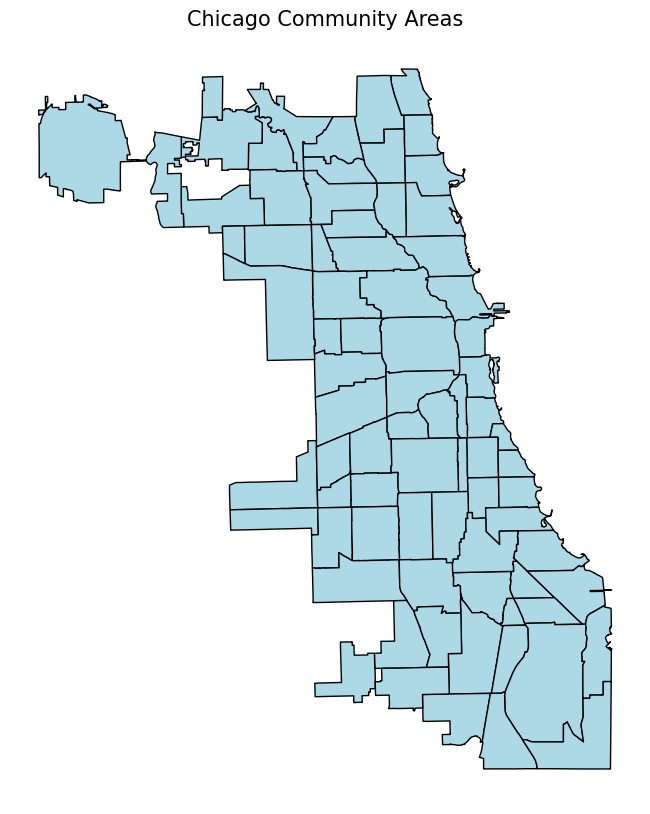

In [ ]:
import matplotlib.pyplot as plt

# Community Area 시각화
fig, ax = plt.subplots(figsize=(10, 10))  # 크기 조정
community_areas_gdf.plot(ax=ax, color='lightblue', edgecolor='black')  # 커뮤니티 영역 시각화

# 제목 추가
ax.set_title("Chicago Community Areas", fontsize=15)

# 축 숨기기
ax.set_axis_off()

# 시각화 출력
plt.show()

In [ ]:
# 5. Ward CSV 파일 불러오기 (the_geom을 WKT 형식으로 변환)
wards = pd.read_csv('/content/drive/MyDrive/final_csv/Wards_2003_2015.csv')  # Ward 데이터 (CSV)
wards['geometry'] = wards['the_geom'].apply(wkt.loads)  # the_geom을 WKT로 변환
wards_gdf = gpd.GeoDataFrame(wards, geometry='geometry', crs="EPSG:4326")

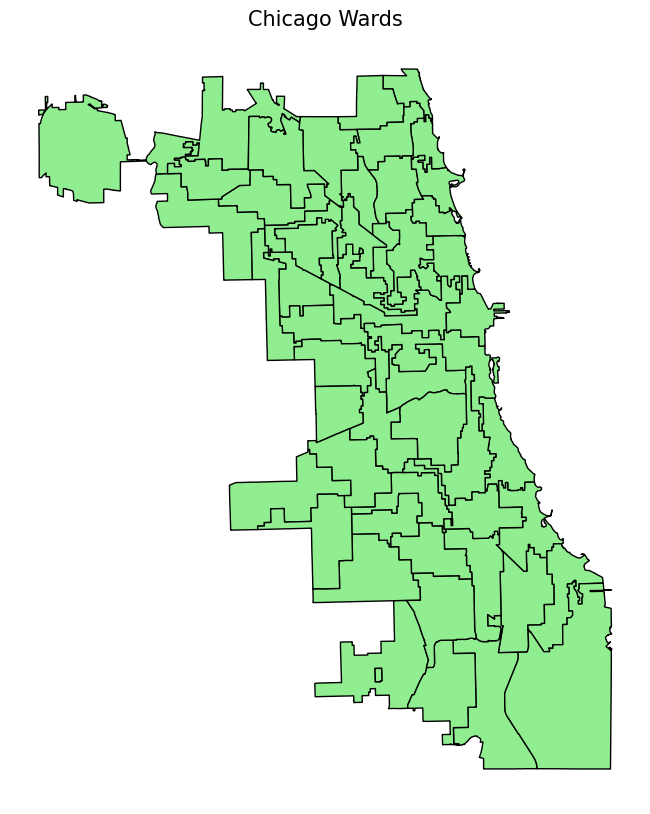

In [ ]:
import matplotlib.pyplot as plt

# Ward 시각화
fig, ax = plt.subplots(figsize=(10, 10))  # 크기 조정
wards_gdf.plot(ax=ax, color='lightgreen', edgecolor='black')  # Ward 영역 시각화

# 제목 추가
ax.set_title("Chicago Wards", fontsize=15)

# 축 숨기기
ax.set_axis_off()

# 시각화 출력
plt.show()


In [ ]:
wards_gdf = wards_gdf[wards_gdf['WARD'] != 'OUT']

In [ ]:
wards_gdf= wards_gdf.dropna(subset=['WARD'])

# int로 변환 후 float로 변환
wards_gdf['WARD'] = wards_gdf['WARD'].astype(float)

In [ ]:
wards_gdf['WARD'].unique()

array([ 4., 33., 49., 37., 18., 31., 25.,  8., 26., 28.,  3., 47.,  1.,
       38., 11., 30., 39., 12.,  9.,  6.,  5., 19., 41., 23., 24., 46.,
       44., 36., 48., 27., 50.,  7., 15., 34., 40., 10.,  2., 22., 35.,
       32., 17., 21., 16., 45., 42., 13., 14., 43., 29., 20.])

In [ ]:
# 6. 범죄 데이터의 좌표가 어느 Ward에 속하는지 Spatial Join
crime_with_ward = gpd.sjoin(crime_gdf, wards_gdf[['WARD', 'geometry']], how='left', predicate='within')  # Ward 매핑

In [ ]:
wards_gdf.head()

,the_geom,DATA_ADMIN,PERIMETER,WARD,ALDERMAN,CLASS,WARD_PHONE,HALL_PHONE,HALL_OFFIC,ADDRESS,EDIT_DATE1,SHAPE_AREA,SHAPE_LEN,geometry
0,MULTIPOLYGON (((-87.61720985189288 41.84565509...,9.588452e+07,71516.462726,4,WILLIAM BURNS,3.0,773-536-8103,312-744-2690,"121 N LASALLE ST, RM 300 OFFICE 10, 60602",4659 S COTTAGE GROVE STE 203,20030527,9.693978e+07,73428.701824,"MULTIPOLYGON (((-87.61721 41.84566, -87.61692 ..."
1,MULTIPOLYGON (((-87.69441592800892 41.95563904...,6.278870e+07,46189.174036,33,RICHARD F. MELL,3.0,773-478-8040,312-744-6825,"121 N LASALLE ST, RM 208, 60602",3649 N KEDZIE AV,20020301,6.278870e+07,46189.173373,"MULTIPOLYGON (((-87.69442 41.95564, -87.69443 ..."
2,MULTIPOLYGON (((-87.6642015105961 42.021260262...,4.685230e+07,44816.944176,49,JOSEPH A. MOORE,5.0,773-338-5796,312-744-3067,"121 N LASALLE ST, RM 300 OFFICE 24, 60602",7356 N GREENVIEW AV,20030527,4.682849e+07,45091.156684,"MULTIPOLYGON (((-87.6642 42.02126, -87.66419 4..."
3,MULTIPOLYGON (((-87.77086308398384 41.92416619...,8.526330e+07,60411.795941,37,EMMA MITTS,2.0,773-745-2894,312-744-8019,"121 N. LASALLE ST, RM 300, 60602",5344 W NORTH AVE,20030527,8.526330e+07,60411.795499,"MULTIPOLYGON (((-87.77086 41.92417, -87.77085 ..."
4,MULTIPOLYGON (((-87.82815431483685 41.98357156...,5.490751e+06,16209.674429,OUT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.475219e+06,16252.000891,"MULTIPOLYGON (((-87.82815 41.98357, -87.82815 ..."


In [ ]:
# 7. 범죄 데이터의 좌표가 어느 Community Area에 속하는지 Spatial Join
crime_with_community = gpd.sjoin(crime_with_ward, community_areas_gdf[['AREA_NUMBE', 'geometry']], how='left', predicate='within', lsuffix='_ward', rsuffix='_community')  # Community Area 매핑

In [ ]:
# 8. 'Ward'와 'Community Area' 결측치 채우기
crime_with_community['Ward'] = crime_with_community['Ward'].fillna(crime_with_community['WARD'])
crime_with_community['Community Area'] = crime_with_community['Community Area'].fillna(crime_with_community['AREA_NUMBE'])

In [ ]:
# 9. 불필요한 열 삭제 (매핑된 'WARD', 'COMMUNITY' 열 제거)
crime_with_community = crime_with_community.drop(columns=['WARD', 'index_right','index__community', 'AREA_NUMBE'])

In [ ]:
crime_with_community = crime_with_community.drop(columns=['geometry'])

In [ ]:
# 10. 결측치 확인
print(crime_with_community[['Ward', 'Community Area']].isna().sum())  # 결측치 확인

Ward              534
Community Area    462
dtype: int64


In [ ]:
crime_with_community.isna().sum()

,0
Unnamed: 0,0
ID,0
Case Number,0
Date,0
Block,0
IUCR,0
Primary Type,0
Description,0
Location Description,13
Arrest,0


In [ ]:
crime_with_community.head()

,Unnamed: 0,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
1,2544,4676906,HM278933,03/01/2003 12:00:00 AM,004XX W 42ND PL,2825,OTHER OFFENSE,HARASSMENT BY TELEPHONE,RESIDENCE,False,...,11.0,61.0,26,1173974.0,1876757.0,2003.0,04/15/2016 08:55:02 AM,41.817229,-87.637328,"(41.817229156, -87.637328162)"
4,3302,4677901,HM275615,05/01/2003 01:00:00 AM,111XX S NORMAL AVE,0841,THEFT,FINANCIAL ID THEFT:$300 &UNDER,RESIDENCE,False,...,34.0,49.0,06,1174948.0,1831051.0,2003.0,04/15/2016 08:55:02 AM,41.691785,-87.635116,"(41.691784636, -87.635115968)"
6,3756,4791194,HM403711,01/01/2001 11:00:00 AM,114XX S ST LAWRENCE AVE,0266,CRIM SEXUAL ASSAULT,PREDATORY,RESIDENCE,True,...,9.0,50.0,02,1182247.0,1829375.0,2001.0,08/29/2006 03:46:28 AM,41.68702,-87.608445,"(41.687020002, -87.60844523)"
7,4502,4679521,HM216293,03/15/2003 12:00:00 AM,090XX S RACINE AVE,5007,OTHER OFFENSE,OTHER WEAPONS VIOLATION,RESIDENCE PORCH/HALLWAY,False,...,21.0,73.0,26,1169911.0,1844832.0,2003.0,04/15/2016 08:55:02 AM,41.729712,-87.653159,"(41.729712374, -87.653158513)"
9,4904,4680124,HM282389,01/01/2003 12:00:00 AM,009XX S SPAULDING AVE,0840,THEFT,FINANCIAL ID THEFT: OVER $300,RESIDENCE,False,...,24.0,29.0,06,1154521.0,1895755.0,2003.0,04/15/2016 08:55:02 AM,41.869772,-87.708180,"(41.869772159, -87.708180162)"


In [ ]:
crime_with_community['Community Area'].unique()

array([61., 49., 50., 73., 29., 65., 59., 66., 23., 62., 67., 70., 10.,
       25., 43., 28., 22., 68., 30., 40., 19.,  3., 71., 42., 34., 63.,
       55., 35., 27., 48., 72., 69., 18., 15., 12.,  7., 52., 60., 58.,
       44., 24., 74.,  5., 56., 21.,  8., 32., 33., 38., 16., 26.,  1.,
       31., 41., 51.,  6., 46., 57., 77., 75.,  2., 53., 14., 39., 13.,
       17.,  4., 11., 54., 64.,  9., 20., 45., 76., nan, 37., 47., 36.,
        0.])

In [ ]:
crime_with_community['Ward'].unique()

array([11., 34.,  9., 21., 24., 13., 15., 26., 12., 18., 41., 37.,  5.,
        2.,  6., 22., 20., 31., 28., 46., 17., 25., 14., 30., 48., 10.,
       27.,  4., 16.,  8., 19., 36., 38., 45., 32.,  1.,  7., 23., 33.,
       42.,  3., 49., 29., 35., 43., 44., 50., 39., 40., 47., nan])

In [ ]:
len(crime_with_community[crime_with_community['Ward']=='OUT'])

41

In [ ]:
# 11. 결과를 CSV로 저장
crime_with_community.to_csv('/content/drive/MyDrive/chicago_crime_data_with_ward_community1.csv', index=False)


In [ ]:
crime_with_community[['ID', 'Ward', 'Community Area']]

,ID,Ward,Community Area
1,4676906,11.0,61.0
4,4677901,34.0,49.0
6,4791194,9.0,50.0
7,4679521,21.0,73.0
9,4680124,24.0,29.0
...,...,...,...
1923510,4781176,37.0,19.0
1923511,4671197,38.0,15.0
1923512,4671380,18.0,71.0
1923513,4782588,10.0,46.0
